In [3]:
import pandas as pd

In [ ]:
pd.read_csv("data/pokemon.csv", usecols=["speed","type1"])

,speed,type1
0,45,grass
1,60,grass
2,80,grass
3,65,fire
4,80,fire
...,...,...
796,61,steel
797,109,grass
798,43,dark
799,79,psychic


In [ ]:
import requests

url = "https://rottentomato.p.rapidapi.com/"

querystring = {"name":"Tangerines"}

headers = {
    "X-RapidAPI-Key": "YOUR_API_KEY",
    "X-RapidAPI-Host": "rottentomato.p.rapidapi.com"
}

response = requests.get(url, headers=headers)

response = response.json()

# Web Scraping

In [7]:
from bs4 import BeautifulSoup
import requests

In [8]:
def convert_stringToInteger(s):
    s = str(s)

    if s=="--":
        return 0
    if s.endswith('L') or s.endswith('l'):
        return int(float(s[:-1]) * 100000)
    
    elif s.endswith('K') or s.endswith('k'):
        return int(float(s[:-1]) * 1000)
    
    elif s.endswith('CR') or s.endswith('cr'):
        return int(float(s[:-2]) * 10000000)
    
    else:
        return int(float(s))

In [9]:
headers = {
    "user-agent": "Mozilla/5.0 (Windows NT 10.0; Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}
company_name = []
rating = []
rating_count = []
details = []
salary = []
benefits = []
for i in range(1,100):
    webpage = requests.get(f"https://www.ambitionbox.com/list-of-companies?sortBy=popular&page={i}", headers=headers).text
    soup = BeautifulSoup(webpage, "html.parser")

    for i in soup.find_all("h2", class_="companyCardWrapper__companyName"):
        company_name.append(i.text.strip())
    
    for i in soup.find_all("div", class_= "rating_text"):
        rating.append(i.text.strip())

    for i in soup.find_all("span", class_= "companyCardWrapper__companyRatingCount"):
        rating_count.append(convert_stringToInteger(i.text.strip().upper().replace("(", "").replace(")", "").replace(",", "")))

    for i in soup.find_all("span", class_ = "companyCardWrapper__ActionCount"):
        details.append(convert_stringToInteger(i.text.strip()))

for i in range(1, len(details), 6):
    salary.append(details[i])
for i in range(4, len(details), 6):
    benefits.append(details[i])
rating = list(map(float, rating))

In [10]:
company_info = pd.DataFrame({
    "company Name": company_name,
    "rating": rating,
    "reviews": rating_count,
    "avg_salary": salary,
    "benefits": benefits
})
company_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company Name  1980 non-null   str    
 1   rating        1980 non-null   float64
 2   reviews       1980 non-null   int64  
 3   avg_salary    1980 non-null   int64  
 4   benefits      1980 non-null   int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 107.9 KB


# How big is the data ?

In [13]:
company_info.shape

(1980, 5)

# How the data looks ?

In [14]:
company_info.head()

,company Name,rating,reviews,avg_salary,benefits
0,TCS,3.3,110000,1019999,10800
1,Accenture,3.7,73800,700000,6800
2,Wipro,3.6,65400,490000,4700
3,Cognizant,3.7,61700,610000,5500
4,Capgemini,3.6,53700,490000,3700


# Check the data types of columns

In [15]:
company_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company Name  1980 non-null   str    
 1   rating        1980 non-null   float64
 2   reviews       1980 non-null   int64  
 3   avg_salary    1980 non-null   int64  
 4   benefits      1980 non-null   int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 107.9 KB


# How many null values are there ?

In [17]:
company_info.isnull().sum()

company Name    0
rating          0
reviews         0
avg_salary      0
benefits        0
dtype: int64

# Is there any duplicate row ?

In [18]:
company_info.duplicated().sum()

np.int64(8)

# How is the correlation btw cols ?

In [20]:
company_info.corr(numeric_only=True)["avg_salary"]


rating       -0.066619
reviews       0.910431
avg_salary    1.000000
benefits      0.924685
Name: avg_salary, dtype: float64

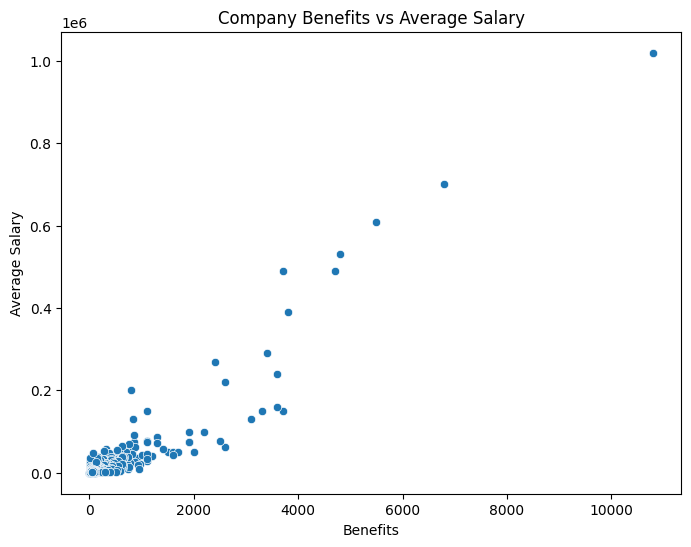

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=company_info, x="benefits", y="avg_salary")
plt.title("Company Benefits vs Average Salary")
plt.xlabel("Benefits")
plt.ylabel("Average Salary")
plt.show()


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error  as mse

X = company_info[["benefits"]]
y = company_info["avg_salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict([[4.9]])

mse(y_test, model.predict(X_test))
model.score(X_test, y_test)

C:\Users\Keval\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


0.8931564289941001